# 0. Unsupervised mode association

## Data loading

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'pandas'

In [ ]:
def read_data(file_path):
    data = pd.read_csv(file_path, sep=';', decimal=',')
    data['Fecha'] = pd.to_datetime(data['Fecha'], format='%d/%m/%Y %H:%M')
    grid_mapping = {
        '0': 0,
        'A1': 1,
        'A2': 4,
        'A3': 7,
        'B1': 2,
        'B2': 5,
        'B3': 8,
        'C1': 3,
        'C2': 6,
        'C3': 9
    }
    data['Cuadricula'] = data['Cuadricula'].map(grid_mapping)
    return data

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath='2_OMA_600.csv'

In [ ]:
data = read_data(filepath)

In [ ]:
sensores=24

In [ ]:
def count_fi_columns(df):
  """Counts the number of columns in a DataFrame that follow the format 'fi'.

  Args:
    df: The pandas DataFrame.

  Returns:
    The number of columns matching the pattern.
  """
  pattern = re.compile(r'^f\d+$')  # Regular expression to match 'f' followed by one or more digits
  fi_columns = [col for col in df.columns if pattern.match(col)]
  return len(fi_columns)

In [ ]:
def drop_columns(df):

    # Get a list of columns matching the pattern
    columns_to_drop = [f'f{i}' for i in range(7, 11)]
    columns_to_drop += [f'x{i}' for i in range(7, 11)]
    columns_to_drop += [f'phi_re_{i}_{j}' for i in range(7, 11) for j in range(24)]
    columns_to_drop += [f'phi_im_{i}_{j}' for i in range(7, 11) for j in range(24)]

    # Drop the identified columns
    df = df.drop(columns=columns_to_drop)

    return df

In [ ]:
#data = drop_columns(data)
data = data.drop(columns=['Peso', 'Fecha'])

In [ ]:
sensores = 24

In [ ]:
data.tail()

,Cuadricula,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,phi_re_10_19,phi_im_10_19,phi_re_10_20,phi_im_10_20,phi_re_10_21,phi_im_10_21,phi_re_10_22,phi_im_10_22,phi_re_10_23,phi_im_10_23
945,9,3.794537,6.119442,8.361846,12.034550,13.049540,14.074826,16.012331,17.529398,21.189842,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
946,9,3.790707,6.154517,8.456516,9.872427,12.028709,13.040572,14.104690,16.020473,17.528900,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
947,9,3.788214,6.195023,12.060802,13.037260,14.176409,16.003500,17.538433,21.178323,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
948,9,3.790317,6.104749,8.360450,12.057675,13.024591,14.106662,16.012949,17.529411,19.440351,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
949,9,3.787989,6.101466,8.370824,12.026626,13.045424,14.075327,16.019136,17.528620,19.446120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Migrate to module and phase

In [ ]:
# Function to calculate module and phase
def calculate_module_phase(row, i, j):
  """
  Calculates the module and phase for a given row and i, j values.

  Args:
    row: A row of the DataFrame.
    i: The index for the frequency/mode.
    j: The index for the sensor/measurement point.

  Returns:
    A tuple containing the module and phase.
  """
  real_part = row[f'phi_re_{i}_{j}']
  imag_part = row[f'phi_im_{i}_{j}']
  module = np.sqrt(real_part**2 + imag_part**2)
  phase = np.arctan2(imag_part, real_part)
  return module, phase

In [ ]:
# Get a list of all phi_re_i_j and phi_im_i_j columns
phi_re_cols = [col for col in data.columns if col.startswith('phi_re_')]
phi_im_cols = [col for col in data.columns if col.startswith('phi_im_')]

# Extract i and j values from column names
ij_values = [(int(col.split('_')[2]), int(col.split('_')[3])) for col in phi_re_cols]

# Create new columns using NumPy for efficiency
modules = np.zeros((len(data), len(phi_re_cols)))
phases = np.zeros((len(data), len(phi_re_cols)))

for idx, (i, j) in enumerate(ij_values):
  real_part = data[f'phi_re_{i}_{j}'].values
  imag_part = data[f'phi_im_{i}_{j}'].values
  modules[:, idx] = np.sqrt(real_part**2 + imag_part**2)
  phases[:, idx] = np.arctan2(imag_part, real_part)

# Create DataFrame for new columns
module_phase_df = pd.DataFrame(
    np.concatenate([modules, phases], axis=1),
    columns=[f'module_{i}_{j}' for i, j in ij_values] +
            [f'phase_{i}_{j}' for i, j in ij_values],
    index=data.index
)

# Concatenate with original DataFrame
data = pd.concat([data, module_phase_df], axis=1)

In [ ]:
# Normalize the phase
for i in range(count_fi_columns(data)):  # Assuming 8 frequencies/modes
    # Get the phase column for j=0
    phase_j0_col = f'phase_{i}_0'

    # Loop through the other j values (1 to 23)
    for j in range(sensores):
        # Get the phase column for the current j
        phase_col = f'phase_{i}_{j}'

        # Subtract the phase of j=0 from the current phase
        data[phase_col] = data[phase_col] - data[phase_j0_col]

In [ ]:
data

,Cuadricula,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,phase_10_14,phase_10_15,phase_10_16,phase_10_17,phase_10_18,phase_10_19,phase_10_20,phase_10_21,phase_10_22,phase_10_23
0,0,3.801042,6.273396,8.540429,9.922279,12.136962,13.382845,16.065817,17.532430,20.412414,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,3.794547,6.200359,8.532843,12.129559,13.390232,14.342439,16.066791,17.528892,20.416269,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,3.806842,6.256350,8.536532,12.132382,13.401080,14.234502,16.071881,17.528668,20.428054,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,3.799239,6.250588,8.535497,13.388185,14.349829,16.067165,17.528341,20.423852,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,3.797240,6.219963,8.536323,12.241676,13.405687,16.062901,17.533739,20.429039,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,9,3.794537,6.119442,8.361846,12.034550,13.049540,14.074826,16.012331,17.529398,21.189842,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
946,9,3.790707,6.154517,8.456516,9.872427,12.028709,13.040572,14.104690,16.020473,17.528900,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
947,9,3.788214,6.195023,12.060802,13.037260,14.176409,16.003500,17.538433,21.178323,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
948,9,3.790317,6.104749,8.360450,12.057675,13.024591,14.106662,16.012949,17.529411,19.440351,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data sorting

In [ ]:
def adapt_df(df):
  # Create an empty list to store the adapted rows
  adapted_rows = []

  # Iterate over each row of the original DataFrame
  for index, row in df.iterrows():
    # Iterate over the values of 'i'
    for i in range(count_fi_columns(df)):
      # Check if 'fi' is not 0
      if row[f'f{i}'] != 0:
        # Create a new dictionary for each adapted row
        adapted_row = {
            'id': index,
            'Cuadricula': row['Cuadricula'],
            'f': row[f'f{i}'],
            #'x': row[f'x{i}'],
        }
        # Iterate over the values of 'j' from 0 to 24
        for j in range(sensores):
          adapted_row[f'module_{j}'] = row[f'module_{i}_{j}']
          #adapted_row[f'phase_{j}'] = row[f'phase_{i}_{j}']
          #adapted_row[f're_{j}'] = row[f'phi_re_{i}_{j}']
          #adapted_row[f'im_{j}'] = row[f'phi_im_{i}_{j}']

        # Append the adapted row to the list
        adapted_rows.append(adapted_row)

  # Create a new DataFrame from the adapted rows
  adapted_df = pd.DataFrame(adapted_rows)

  return adapted_df

In [ ]:
adapted_data = adapt_df(data)
adapted_data

,id,Cuadricula,f,module_0,module_1,module_2,module_3,module_4,module_5,module_6,...,module_14,module_15,module_16,module_17,module_18,module_19,module_20,module_21,module_22,module_23
0,0,0.0,3.801042,0.293913,0.106027,0.000514,0.382119,0.108825,0.018036,0.119876,...,0.006638,1.000000,0.347605,0.020001,0.293151,0.314596,0.009689,0.556714,0.304427,0.012197
1,0,0.0,6.273396,0.370712,0.665419,0.012853,0.373365,0.675101,0.004808,0.341476,...,0.012388,0.567510,0.949144,0.015213,0.528654,0.964433,0.013811,0.558063,0.972856,0.011680
2,0,0.0,8.540429,0.145655,0.144830,0.032415,0.151105,0.131089,0.013653,0.786456,...,0.014418,0.524621,0.187230,0.014034,1.000000,0.215976,0.050662,0.463678,0.149377,0.028165
3,0,0.0,9.922279,0.104902,0.410618,0.019021,0.161307,0.395504,0.014516,0.578273,...,0.048572,1.000000,0.684096,0.042105,0.301066,0.673536,0.033562,0.181779,0.745666,0.031705
4,0,0.0,12.136962,0.190858,0.655916,0.105576,0.097986,0.655792,0.033063,0.461060,...,0.063916,1.000000,0.792715,0.037451,0.078832,0.786489,0.019928,0.355187,0.832614,0.060883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7908,949,9.0,13.045424,0.757427,0.292717,0.037470,1.000000,0.302476,0.018459,0.273843,...,0.006623,0.365807,0.213576,0.031242,0.150081,0.202880,0.018311,0.222684,0.189091,0.005326
7909,949,9.0,14.075327,0.573652,0.166441,0.053697,1.000000,0.157988,0.028674,0.377312,...,0.038083,0.405069,0.304901,0.001524,0.997819,0.261796,0.010852,0.470335,0.295349,0.024104
7910,949,9.0,16.019136,0.020075,0.022402,1.000000,0.011119,0.008753,0.312275,0.003181,...,0.038081,0.012751,0.005925,0.014997,0.025139,0.005049,0.036251,0.010756,0.003854,0.035725
7911,949,9.0,17.528620,0.012269,0.018726,0.115403,0.018033,0.022516,0.037214,0.010406,...,1.000000,0.005695,0.036603,0.384807,0.024611,0.007080,0.814729,0.011730,0.007563,0.840380


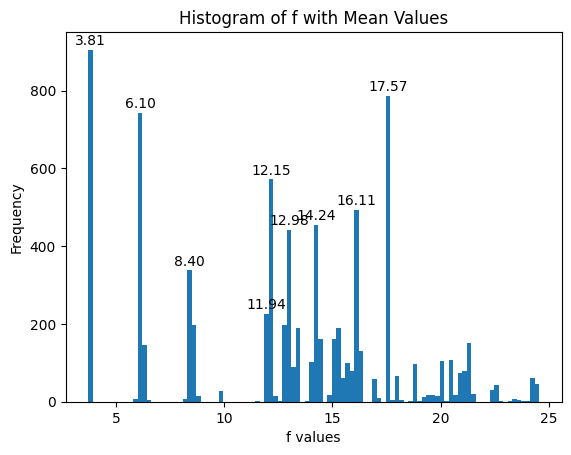

In [ ]:
# Create the histogram
n, bins, patches = plt.hist(adapted_data['f'], bins=100)

# Calculate and display mean values over each bar
bin_centers = 0.5 * (bins[:-1] + bins[1:])  # Calculate bin centers
for i in range(len(patches)):
    if n[i] > 200:  # Check if frequency is greater than 100
        plt.text(bin_centers[i], n[i] + 5, f'{bin_centers[i]:.2f}', ha='center', va='bottom')

# Add labels and title
plt.xlabel('f values')
plt.ylabel('Frequency')
plt.title('Histogram of f with Mean Values')

# Show the plot
plt.show()

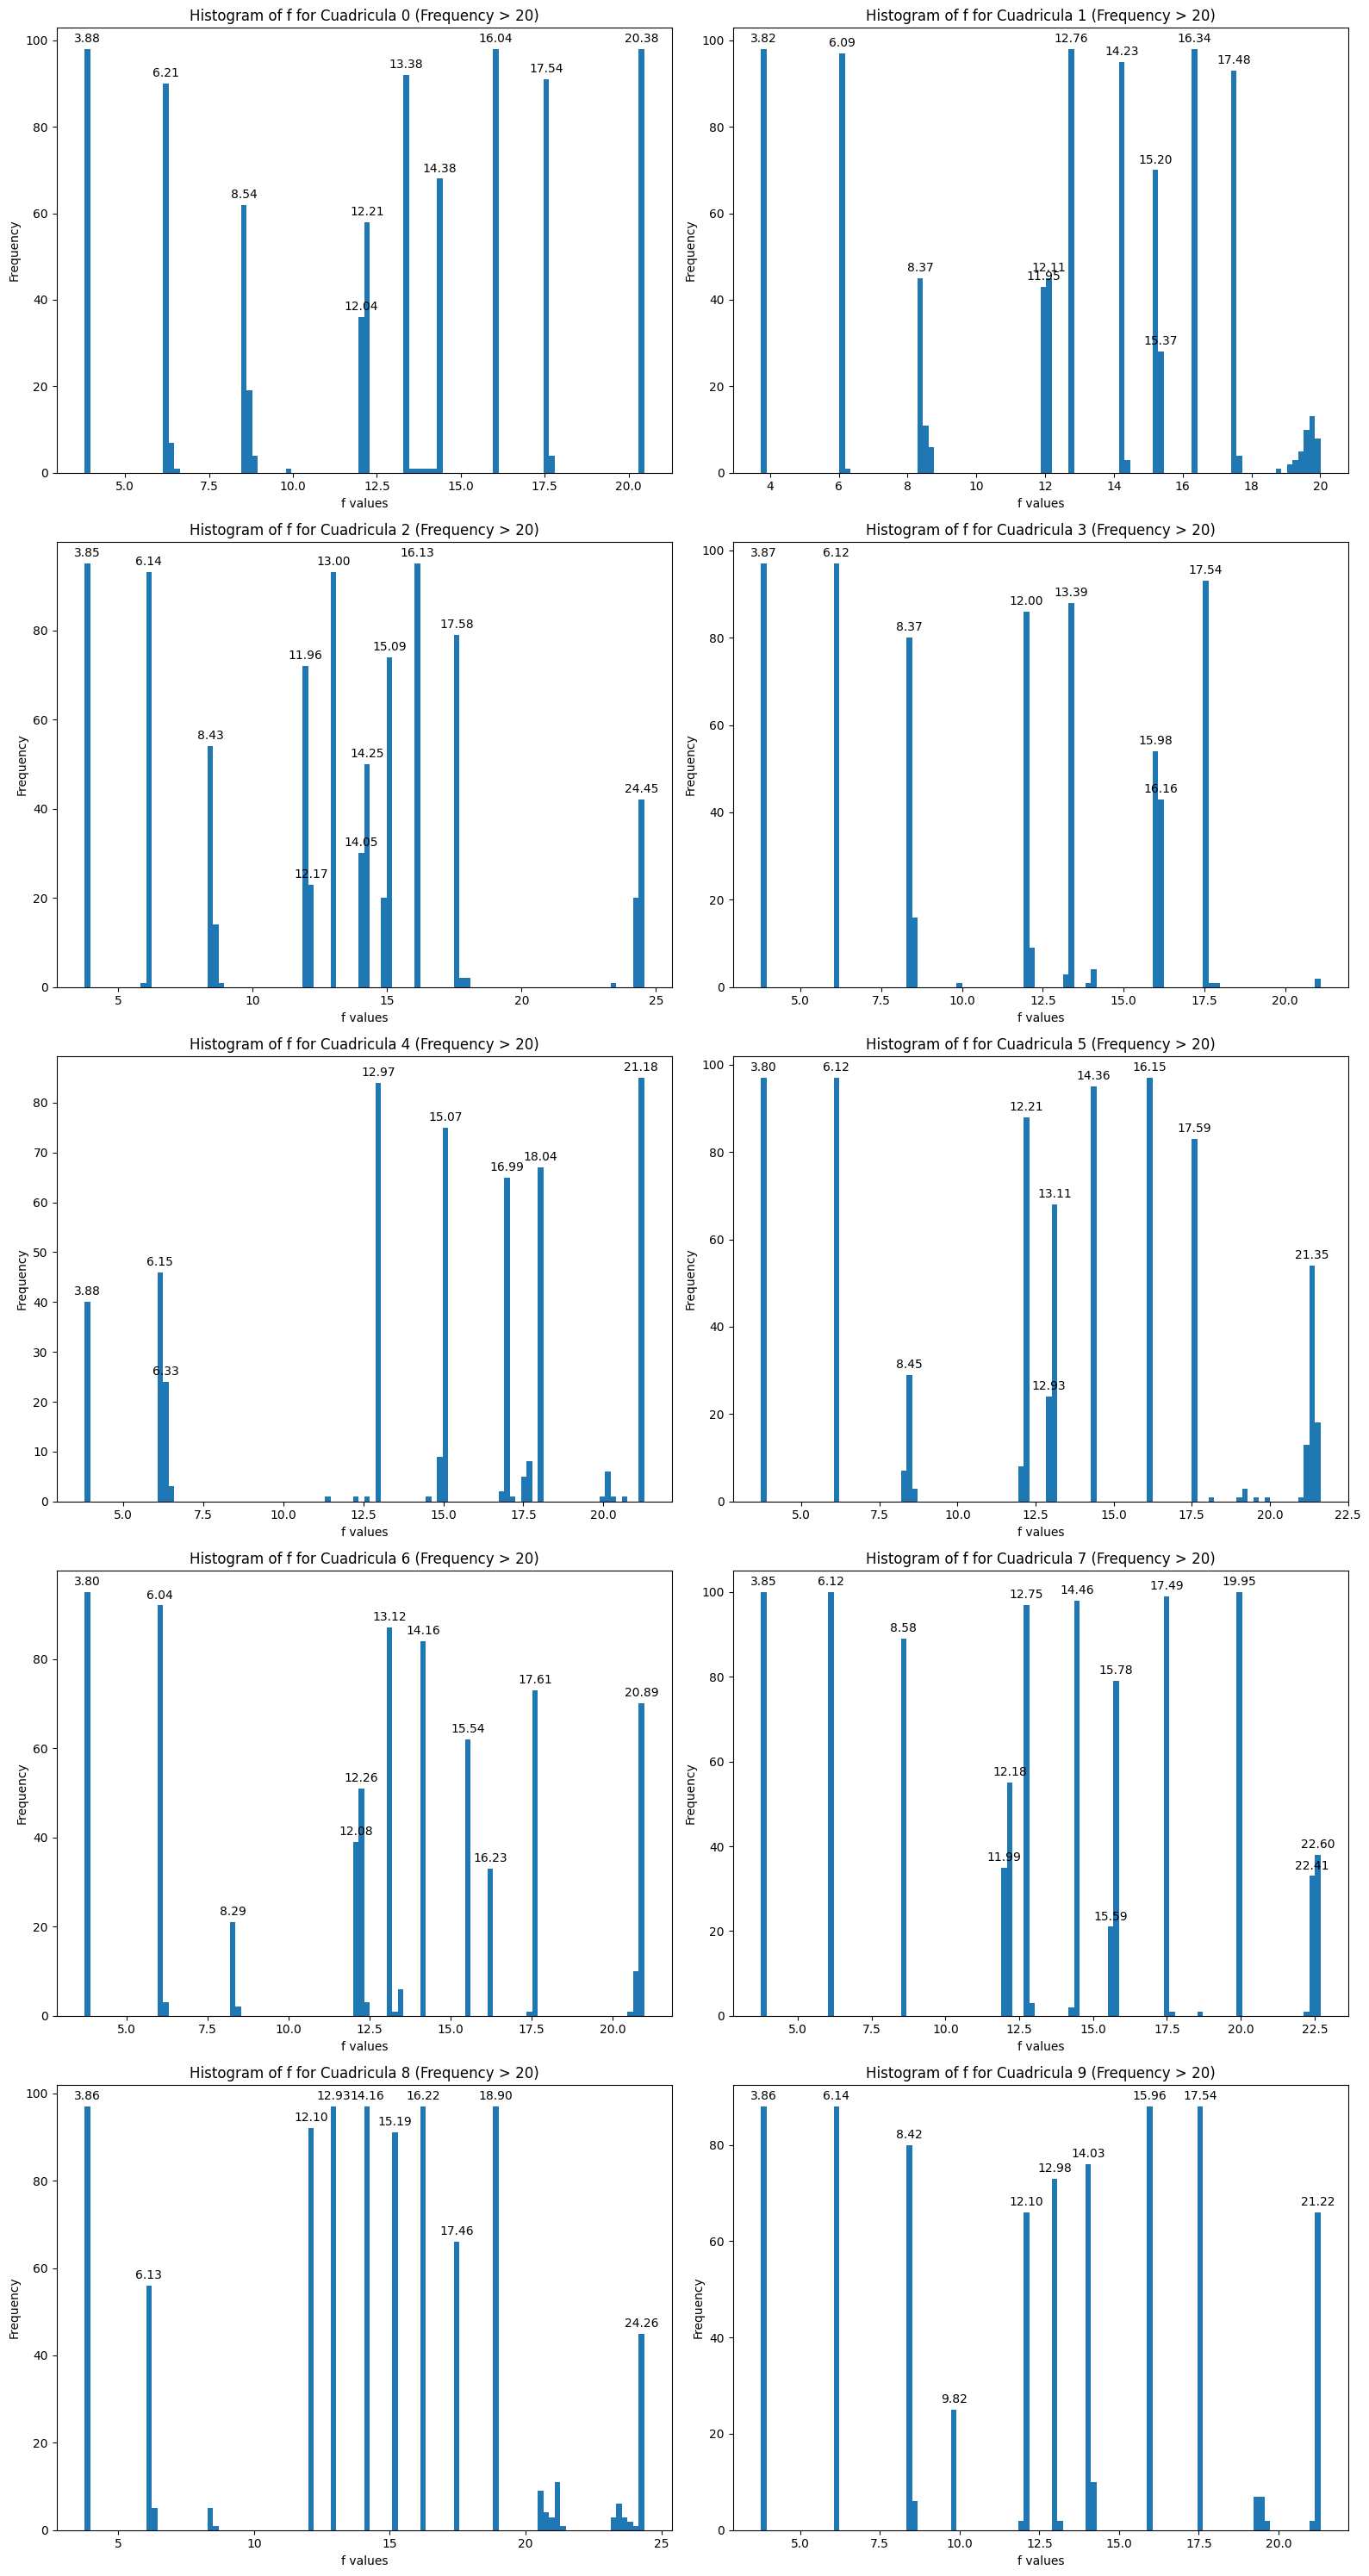

In [ ]:
# Create a figure and subplots
fig, axes = plt.subplots(5, 2, figsize=(16, 30))  # Adjust figsize as needed

# Iterate through unique Cuadricula values
for i in range(10):
    # Calculate row and column index for subplot
    row = i // 2  # Integer division to get row index
    col = i % 2   # Modulo operation to get column index

    # Filter data for the current Cuadricula
    cuadricula_data = adapted_data[adapted_data['Cuadricula'] == i]

    # Create the histogram
    n, bins, patches = axes[row, col].hist(cuadricula_data['f'], bins=100)

    # Calculate and display mean values (only for bars with frequency > 100)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    for j in range(len(patches)):
        if n[j] > 20:
            axes[row, col].text(bin_centers[j], n[j] + (n.max() * 0.01), f'{bin_centers[j]:.2f}', ha='center', va='bottom')

    # Add labels and title
    axes[row, col].set_xlabel('f values')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Histogram of f for Cuadricula {i} (Frequency > 20)')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Search for the number of clusters (k means)

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt

In [ ]:
#adapted_data = adapted_data[adapted_data['Cuadricula'] == 0]

In [ ]:
# Select the relevant columns for clustering
X = adapted_data.drop(columns=['id', 'Cuadricula'])

In [ ]:
# Scale the features using StandardScaler
scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)
X_scaled = X

In [ ]:
k = 21

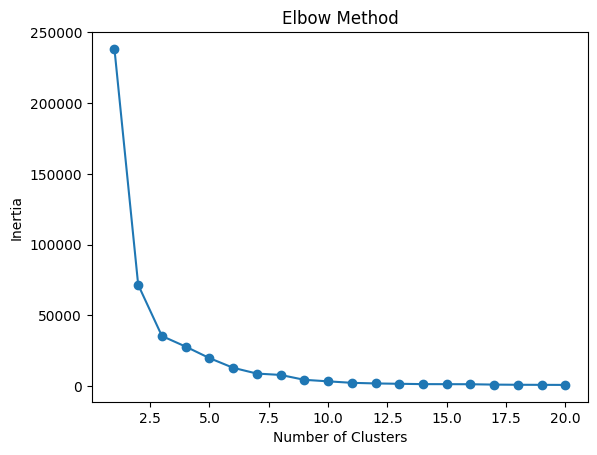

In [ ]:
# Elbow method
inertia = []
for i in range(1, k):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, k), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

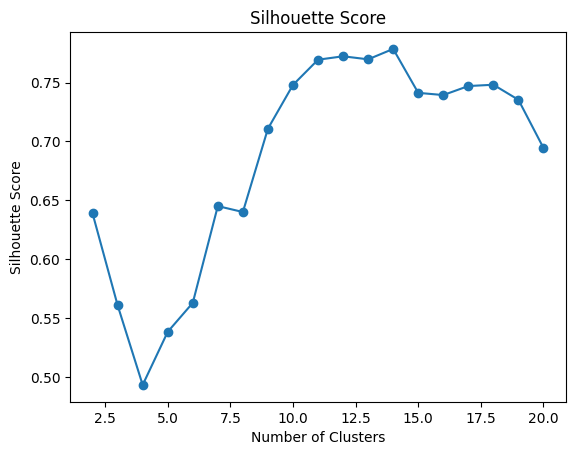

In [ ]:
# Silhouette score
silhouette_scores = []
for i in range(2, k):  # Silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=i, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, clusters))

plt.plot(range(2, k), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
# DECIDO CUÁNTOS CLUSTERS
num_clusters=7

In [ ]:
# Apply KMeans clustering with a specified number of clusters (e.g., 3)
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
# Get the values of 'f' for each centroid
centroides = kmeans.cluster_centers_[:, 0]
#centroides = scaler.inverse_transform(kmeans.cluster_centers_)[:, 0]
np.sort(centroides)

array([ 3.76885809,  6.12972307,  8.52904593, 12.59663433, 15.21293278,
       17.69016035, 21.42072463])

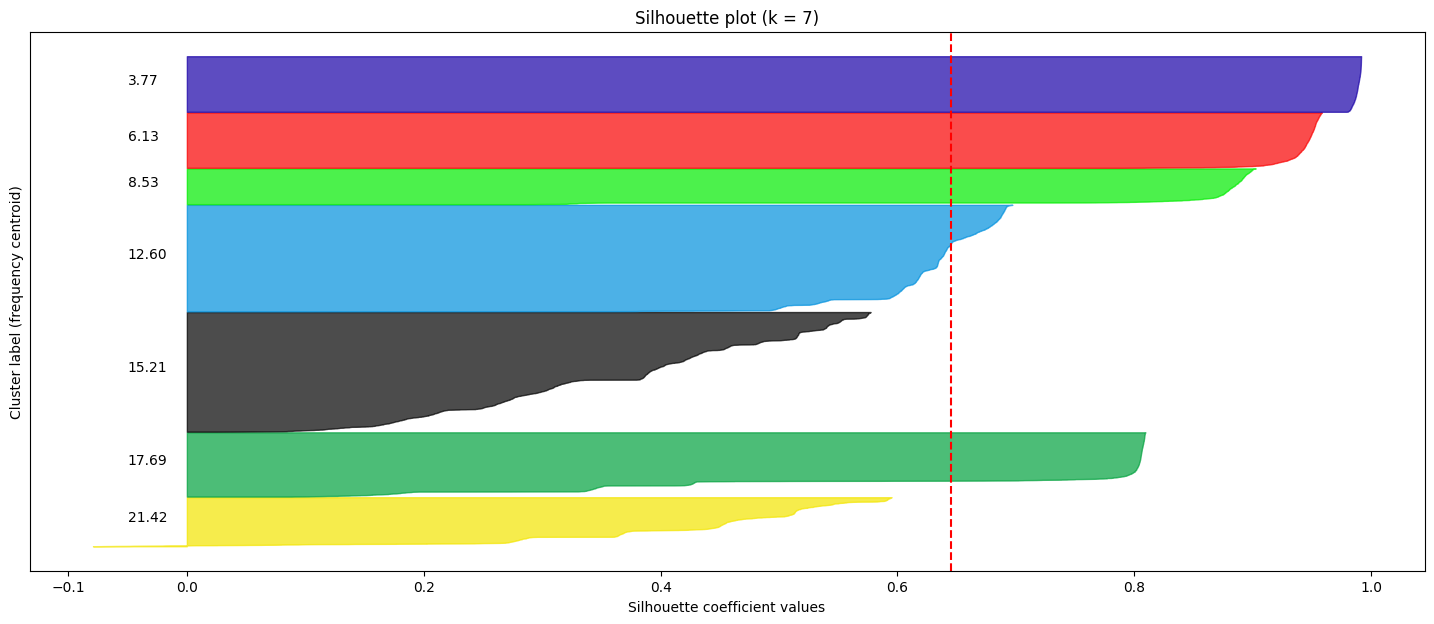

In [ ]:
# Calculate silhouette scores for each sample
silhouette_vals = silhouette_samples(X_scaled, clusters)

# Set up the plot
y_lower = 10  # Starting y position for the first cluster
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(18, 7)

# Sort cluster indices based on centroides
sorted_indices = np.argsort(centroides)
sorted_indices = sorted_indices[::-1]

# Iterate through clusters in sorted order
for i in sorted_indices:
    # Aggregate silhouette scores for samples in current cluster
    ith_cluster_silhouette_vals = silhouette_vals[clusters == i]
    ith_cluster_silhouette_vals.sort()

    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.nipy_spectral(float(i) / num_clusters)  # Choose color for cluster
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_vals,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, f'{centroides[i]:.2f}')

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title(f"Silhouette plot (k = {num_clusters})")
ax1.set_xlabel("Silhouette coefficient values")
ax1.set_ylabel("Cluster label (frequency centroid)")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.show()